<a href="https://colab.research.google.com/github/TK-Problem/random-experiments/blob/main/001_bayesian_linear_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from datetime import date, timedelta
from IPython.display import clear_output

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")

## Configuration

- **Target**: `SPY` (S&P 500 ETF) — the variable we are trying to predict.
- **Predictors**: 8 ETFs/indices covering equity factors, commodities, rates, and volatility.
- **Window**: `N_TRAIN` trading days for training, `N_TEST` most recent days held out.
- **Lag**: predictors are shifted by `LAG=1` day so no future information leaks into features.

In [2]:
N_TRAIN = 60   # Trading days used for training
N_TEST  = 5    # Most recent days reserved for testing
N_DAYS  = N_TRAIN + N_TEST  # Total trading days needed

TARGET    = "SPY"
PREDICTORS = [
    "QQQ",   # Nasdaq 100
    "IWM",   # Russell 2000 (small cap)
    "GLD",   # Gold
    "TLT",   # Long-term Treasuries
    "VIX",   # Volatility index (^VIX in yfinance)
    "XLE",   # Energy sector
    "XLF",   # Financials sector
    "EEM",   # Emerging markets
]

# Request ~1.5x calendar days to guarantee N_DAYS trading days after weekends/holidays
END_DATE   = date.today().strftime("%Y-%m-%d")
START_DATE = (date.today() - timedelta(days=int(N_DAYS * 2))).strftime("%Y-%m-%d")
LAG        = 1   # Days to lag predictors (1 = previous day)
RANDOM_SEED = 42

## Load Data

Download `N_DAYS` worth of adjusted closing prices from Yahoo Finance for all tickers.
`^VIX` is renamed to `VIX` for consistency. Daily log returns `ln(P_t / P_{t-1})` are computed
and the result is trimmed to the `N_DAYS` most recent trading days to keep the window fixed.

In [3]:
print("Downloading price data from Yahoo Finance...")
tickers = [TARGET] + PREDICTORS
# ^VIX needs special handling
yf_tickers = [t if t != "VIX" else "^VIX" for t in tickers]

raw = yf.download(yf_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]

# Rename ^VIX back to VIX
raw.columns = [c.replace("^", "") for c in raw.columns]

# Compute daily log returns
returns = np.log(raw / raw.shift(1)).dropna()
print(f"Downloaded {len(returns)} trading days of data.\n")

[*********************100%***********************]  9 of 9 completed

Downloaded 88 trading days of data.



In [4]:
returns.head()

,EEM,GLD,IWM,QQQ,SPY,TLT,XLE,XLF,VIX
Date,,,,,,,,,
2025-11-05,0.008929,0.011498,0.014325,0.006487,0.003459,-0.010956,0.002634,0.003428,-0.053512
2025-11-06,-0.007466,-0.001201,-0.017855,-0.018803,-0.010787,0.008953,0.009676,-0.003619,0.079487
2025-11-07,-0.002929,0.006100,0.005229,-0.003160,0.000984,-0.002119,0.014285,0.007035,-0.021774
2025-11-10,0.017445,0.026974,0.009966,0.021883,0.015484,-0.000223,0.009006,0.003593,-0.080742
2025-11-11,0.001080,0.003930,0.000860,-0.002667,0.002287,0.004568,0.012976,0.004521,-0.018349


## Feature Engineering

Shift each predictor return back by `LAG` days so that on day *t* the model only sees
information from day *t−1*. The shifted frame and the target are inner-joined and rows
with any NaN (introduced by the shift) are dropped, leaving an aligned `(n_days, n_features)`
design matrix and a `(n_days,)` target vector.

In [5]:
# Target: SPY return on day t
y_series = returns[TARGET].copy()

# Features: each predictor's return on day t-LAG
X_df = returns[PREDICTORS].shift(LAG)

# Align and drop NaNs
df = pd.concat([y_series.rename("target"), X_df], axis=1).dropna()

y = df["target"].values
X_raw = df[PREDICTORS].values

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Target vector shape:  {y.shape}\n")

Feature matrix shape: (87, 8)
Target vector shape:  (87,)



## Train / Test Split

Take the `N_TRAIN + N_TEST` most recent rows and split chronologically — no shuffling to avoid
look-ahead bias. A `StandardScaler` is fitted **only on the training set** and then applied to
the test set, so test statistics are never seen during normalisation.

In [6]:
df_split = df.tail(N_TRAIN + N_TEST)

X_all = df_split[PREDICTORS].values
y_all = df_split["target"].values

X_train_raw, X_test_raw = X_all[:N_TRAIN], X_all[N_TRAIN:]
y_train,      y_test     = y_all[:N_TRAIN], y_all[N_TRAIN:]
dates_test = df_split.index[N_TRAIN:]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {len(y_train)} days  ({df_split.index[0].date()} – {df_split.index[N_TRAIN - 1].date()})")
print(f"Test:  {len(y_test)} days  ({dates_test[0].date()} – {dates_test[-1].date()})")

Train: 60 days  (2025-12-09 – 2026-03-06)
Test:  5 days  (2026-03-09 – 2026-03-13)


## Single-Beta Bayesian Models

For each predictor independently, fit a simple Bayesian linear regression:
`SPY_t = α + β · predictor_{t-1} + ε`. Weakly informative Gaussian priors are placed on `α`
and `β` (centred at 0, reflecting prior belief that daily return predictability is small),
and a `HalfNormal` prior on `σ`. Posterior is sampled via NUTS with 4 chains.

In [7]:
single_traces = {}

print("Fitting single-beta models...\n")
for i, predictor in enumerate(PREDICTORS):
    x_tr = X_train[:, i]

    with pm.Model():
        alpha = pm.Normal("alpha", mu=0, sigma=0.01)
        beta = pm.Normal("beta",  mu=0, sigma=0.05)
        sigma = pm.HalfNormal("sigma", sigma=0.01)
        mu = alpha + beta * x_tr
        _  = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

        trace = pm.sample(
            draws=1000,
            tune=500,
            chains=4,
            target_accept=0.9,
            random_seed=RANDOM_SEED,
            progressbar=False,
        )

    single_traces[predictor] = trace
    b_mean = float(trace.posterior["beta"].values.mean())
    b_std  = float(trace.posterior["beta"].values.std())
    rhat   = float(az.summary(trace, var_names=["beta"])["r_hat"].values[0])
    print(f"  {predictor:6s}  beta={b_mean:+.5f} ± {b_std:.5f}  r_hat={rhat:.3f}")

clear_output(wait=True)
print("All single-beta sampling complete.")

All single-beta sampling complete.


## Single-Beta Evaluation

Apply each single-predictor posterior to the held-out test set. The posterior predictive mean
is used as the point forecast and compared against actual SPY returns via R², RMSE, and
Pearson correlation. This establishes individual baselines before the joint model is built.

In [8]:
print("--- Single-Beta Out-of-Sample Metrics ---\n")
single_metrics = []

for i, predictor in enumerate(PREDICTORS):
    trace = single_traces[predictor]
    x_te = X_test[:, i]
    post_a = trace.posterior["alpha"].values.flatten()
    post_b = trace.posterior["beta"].values.flatten()

    mu_pred = post_a[:, None] + post_b[:, None] * x_te[None, :]
    y_pred_mean = mu_pred.mean(axis=0)

    ss_res = np.sum((y_test - y_pred_mean) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2  = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y_test - y_pred_mean) ** 2))
    corr = np.corrcoef(y_test, y_pred_mean)[0, 1]

    single_metrics.append({"ETF": predictor, "R²": r2, "RMSE": rmse, "Corr": corr})
    print(f"  {predictor:6s}  R²={r2:+.4f}  RMSE={rmse:.6f}  Corr={corr:+.4f}")

single_metrics_df = pd.DataFrame(single_metrics).set_index("ETF")
print(f"\nBest single predictor by R²: {single_metrics_df['R²'].idxmax()}")

--- Single-Beta Out-of-Sample Metrics ---

  QQQ     R²=-0.1130  RMSE=0.008184  Corr=+0.2564
  IWM     R²=-0.1255  RMSE=0.008229  Corr=+0.3465
  GLD     R²=-0.1778  RMSE=0.008419  Corr=-0.6098
  TLT     R²=+0.1284  RMSE=0.007242  Corr=+0.3868
  VIX     R²=+0.0030  RMSE=0.007745  Corr=+0.4763
  XLE     R²=-0.1876  RMSE=0.008453  Corr=-0.6807
  XLF     R²=-0.2064  RMSE=0.008520  Corr=+0.1232
  EEM     R²=-0.1238  RMSE=0.008223  Corr=+0.0393

Best single predictor by R²: TLT


## Multi-Variable Bayesian Linear Regression

Extend the single-beta approach to a joint model:
`SPY_t = α + β₁·X₁ + … + β₈·X₈ + ε`. Fitting all predictors together lets the model
account for inter-predictor correlations and partial out shared variance, which the
single-beta models cannot do. Same prior structure as the single-beta models; 4 chains,
2 000 draws, 1 000 tuning steps.

In [9]:
n_features = X_train.shape[1]

with pm.Model() as model:
    alpha = pm.Normal("alpha", mu=0, sigma=0.01)
    betas = pm.Normal("betas", mu=0, sigma=0.05, shape=n_features)
    sigma = pm.HalfNormal("sigma", sigma=0.01)
    mu = alpha + pm.math.dot(X_train, betas)
    _ = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

    print("Sampling posterior (this may take a minute)...")
    trace = pm.sample(
        draws=2000, tune=1000, chains=4,
        target_accept=0.9, random_seed=RANDOM_SEED,
        progressbar=True,
    )

clear_output(wait=True)
print("\nSampling complete!")
summary = az.summary(trace, var_names=["alpha", "betas", "sigma"], round_to=6)
summary.index = ["alpha"] + [f"beta_{p}" for p in PREDICTORS] + ["sigma"]
print("\n--- Posterior Summary ---")
print(summary.to_string(index=False))


Sampling complete!

--- Posterior Summary ---
     mean       sd    hdi_3%  hdi_97%  mcse_mean  mcse_sd    ess_bulk    ess_tail    r_hat
-0.000241 0.000934 -0.001966 0.001562   0.000010 0.000013 9467.178368 5331.532518 1.000493
-0.000177 0.001777 -0.003512 0.003127   0.000019 0.000021 8546.192443 5667.209828 1.001338
 0.001480 0.001633 -0.001754 0.004385   0.000017 0.000018 8888.778688 6117.727050 1.001260
-0.001379 0.001175 -0.003585 0.000874   0.000013 0.000013 8689.368587 5846.103635 1.000262
 0.001844 0.000953  0.000134 0.003727   0.000010 0.000012 8823.491090 5719.388586 1.000290
 0.002197 0.001786 -0.001178 0.005480   0.000019 0.000022 8454.265355 5720.595253 1.000602
 0.000535 0.001057 -0.001463 0.002471   0.000011 0.000012 9607.059659 6284.251051 1.000187
-0.000732 0.001344 -0.003291 0.001671   0.000015 0.000015 8357.355937 6184.311433 1.000859
 0.001355 0.001470 -0.001315 0.004248   0.000015 0.000018 9101.759261 5669.745640 1.000290
 0.007196 0.000713  0.005920 0.008514   0.0

## In-Sample Diagnostics

**Trace plots**: verify that each chain mixes well (caterpillar-like traces) and that the
marginal distributions across chains agree.

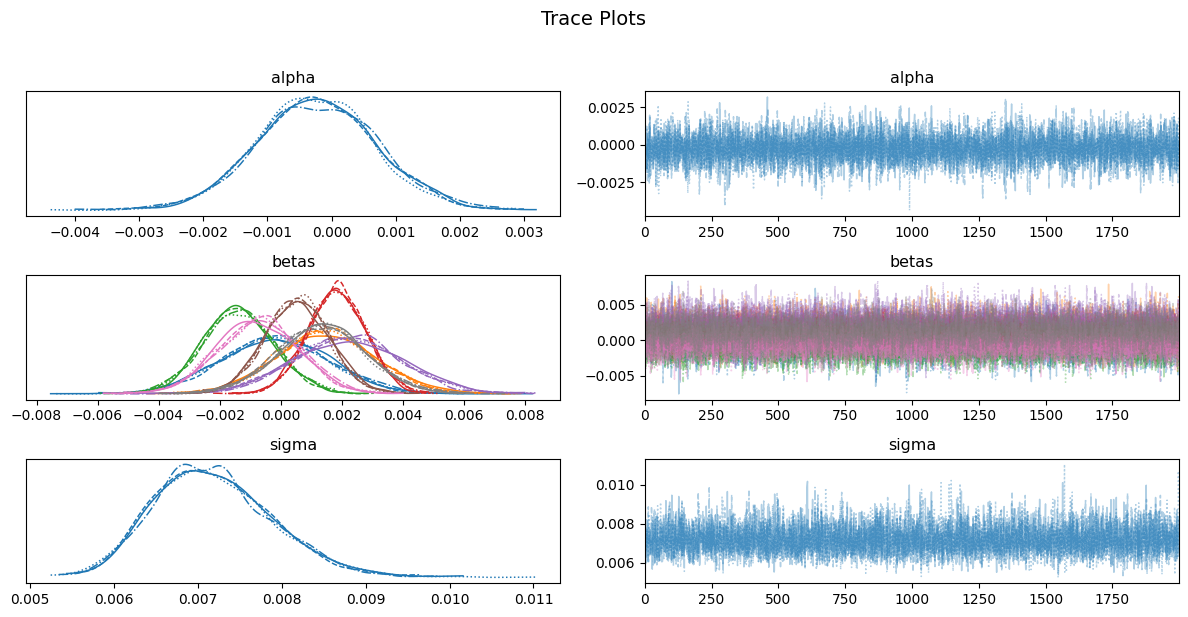

In [10]:
az.plot_trace(trace, var_names=["alpha", "betas", "sigma"], compact=True)
plt.suptitle("Trace Plots", fontsize=14, y=1.02)
plt.tight_layout()

**Forest plot**: shows posterior 94% HDI for each
`β` with R-hat values — R-hat < 1.01 indicates good convergence. A red dashed line at 0
highlights coefficients whose HDI excludes zero (credibly non-zero effects).

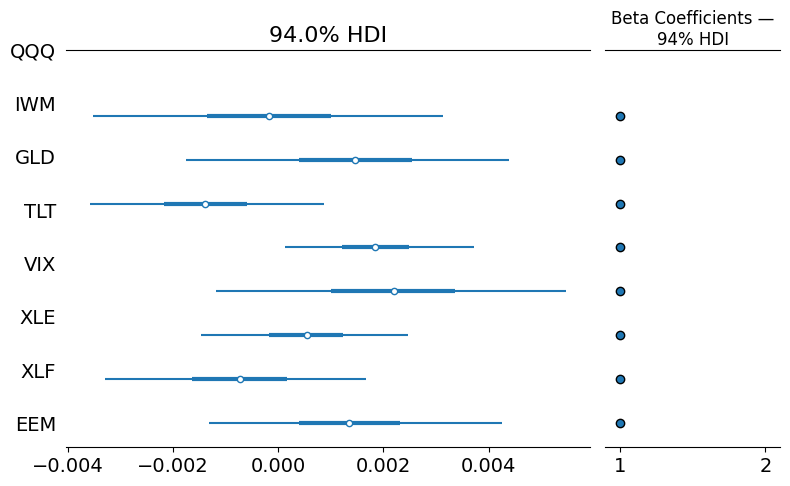

In [11]:
az.plot_forest(trace, var_names=["betas"],
               combined=True, hdi_prob=0.94, r_hat=True)
plt.axvline(0, color="red", linestyle="--", alpha=0.6)
plt.yticks(ticks=range(n_features), labels=PREDICTORS[::-1])
plt.title("Beta Coefficients — 94% HDI")
plt.tight_layout()

plt.show()

## Out-of-Sample Prediction

Generate posterior predictive distributions on the test set by evaluating each posterior
sample `(α⁽ˢ⁾, β⁽ˢ⁾)` against `X_test`. The predictive mean and 94% HDI are derived from
these samples. R², RMSE, and Pearson correlation are reported alongside the single-beta
baselines from the previous section for a direct comparison.

In [12]:
post_alpha = trace.posterior["alpha"].values.flatten()
post_betas = trace.posterior["betas"].values.reshape(-1, n_features)
post_sigma = trace.posterior["sigma"].values.flatten()

mu_pred     = post_alpha[:, None] + post_betas @ X_test.T
y_pred_mean = mu_pred.mean(axis=0)
y_pred_hdi  = az.hdi(mu_pred, hdi_prob=0.94)

ss_res = np.sum((y_test - y_pred_mean) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2   = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean((y_test - y_pred_mean) ** 2))
corr = np.corrcoef(y_test, y_pred_mean)[0, 1]

print("--- Out-of-Sample Metrics Comparison ---\n")
print(f"  {'Model':<20}  {'R²':>8}  {'RMSE':>10}  {'Corr':>8}")
print(f"  {'-'*50}")
for _, row in single_metrics_df.iterrows():
    print(f"  {row.name:<20}  {row['R²']:>+8.4f}  {row['RMSE']:>10.6f}  {row['Corr']:>+8.4f}")
print(f"  {'-'*50}")
print(f"  {'Multi-variable':<20}  {r2:>+8.4f}  {rmse:>10.6f}  {corr:>+8.4f}")

--- Out-of-Sample Metrics Comparison ---

  Model                       R²        RMSE      Corr
  --------------------------------------------------
  QQQ                    -0.1130    0.008184   +0.2564
  IWM                    -0.1255    0.008229   +0.3465
  GLD                    -0.1778    0.008419   -0.6098
  TLT                    +0.1284    0.007242   +0.3868
  VIX                    +0.0030    0.007745   +0.4763
  XLE                    -0.1876    0.008453   -0.6807
  XLF                    -0.2064    0.008520   +0.1232
  EEM                    -0.1238    0.008223   +0.0393
  --------------------------------------------------
  Multi-variable         +0.2512    0.006712   +0.5560


/tmp/ipykernel_5245/4144282547.py:7: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_pred_hdi  = az.hdi(mu_pred, hdi_prob=0.94)


## Visualize Predictions

Two-panel chart for the multi-variable model on the test set:
- **Top**: actual vs. posterior-mean predicted SPY log returns with a 94% HDI band.
- **Bottom**: residuals `(actual − predicted)` as a bar chart to reveal any systematic bias.

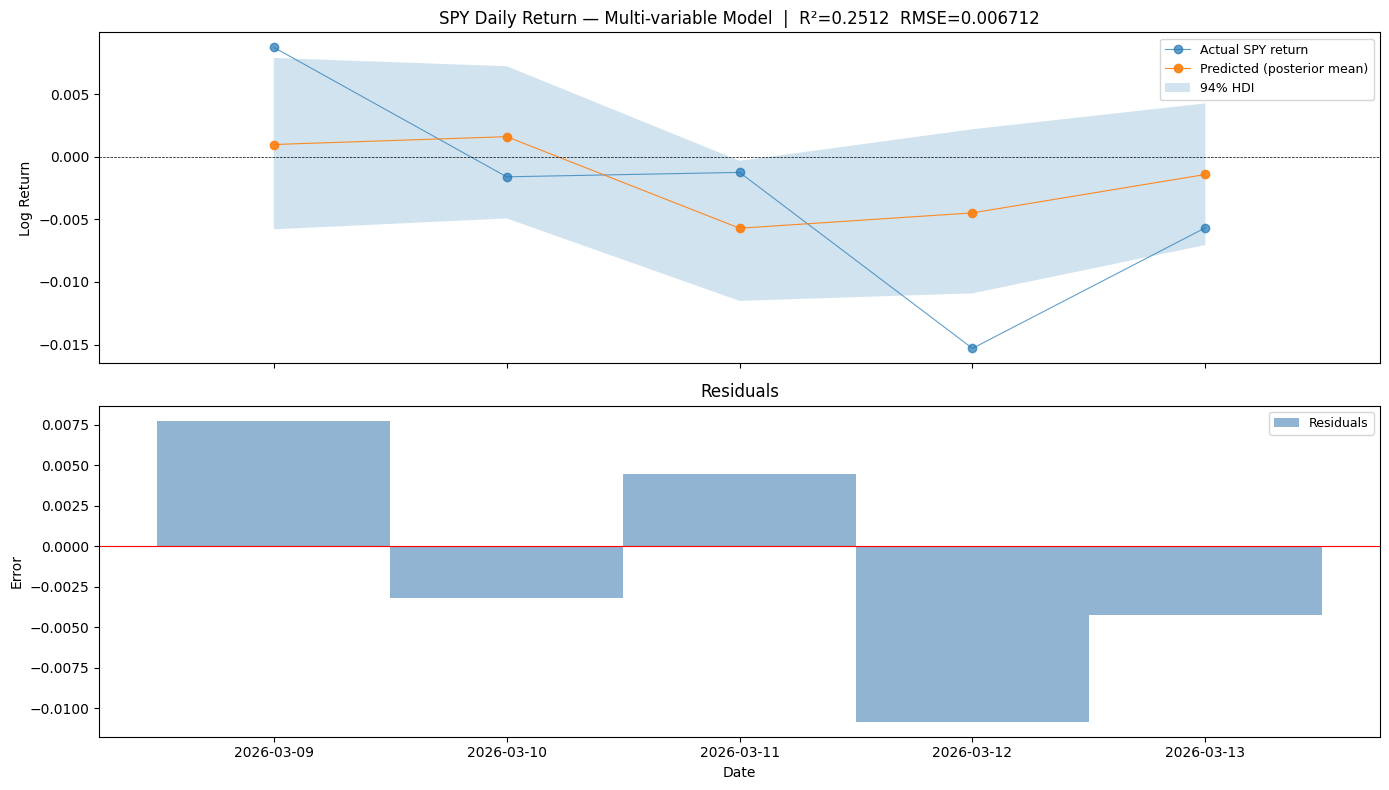

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dates_test, y_test, "o-", label="Actual SPY return", alpha=0.7, linewidth=0.8)
axes[0].plot(dates_test, y_pred_mean, "o-", label="Predicted (posterior mean)",  alpha=0.9, linewidth=0.8)
axes[0].fill_between(dates_test,
                     y_pred_hdi[:, 0], y_pred_hdi[:, 1],
                     alpha=0.2, label="94% HDI")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title(f"SPY Daily Return — Multi-variable Model  |  R²={r2:.4f}  RMSE={rmse:.6f}")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Log Return")

residuals = y_test - y_pred_mean
axes[1].bar(dates_test, residuals, width=1, alpha=0.6, color="steelblue", label="Residuals")
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("Residuals")
axes[1].set_ylabel("Error")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## Coefficient Importance

Rank predictors by their Bayesian signal-to-noise ratio `|β_mean| / β_std` — a higher value
means the posterior is more decisively non-zero relative to its own uncertainty. This is
analogous to a *t*-statistic but operates entirely within the posterior distribution.
The horizontal bar chart shows posterior mean ± 1 std; red = positive effect, blue = negative.

In [14]:
beta_means = post_betas.mean(axis=0)
beta_stds  = post_betas.std(axis=0)

coef_df = pd.DataFrame({
    "ETF": PREDICTORS,
    "beta_mean": beta_means,
    "beta_std": beta_stds,
    "signal": np.abs(beta_means) / beta_stds,
}).sort_values("signal", ascending=False)

print("--- Coefficient Summary (sorted by |mean/std|) ---")
print(coef_df.to_string(index=False))

--- Coefficient Summary (sorted by |mean/std|) ---
ETF  beta_mean  beta_std   signal
TLT   0.001844  0.000953 1.934553
VIX   0.002197  0.001786 1.229960
GLD  -0.001379  0.001175 1.173801
EEM   0.001355  0.001469 0.921780
IWM   0.001480  0.001632 0.906842
XLF  -0.000732  0.001344 0.544918
XLE   0.000535  0.001057 0.506420
QQQ  -0.000177  0.001777 0.099683


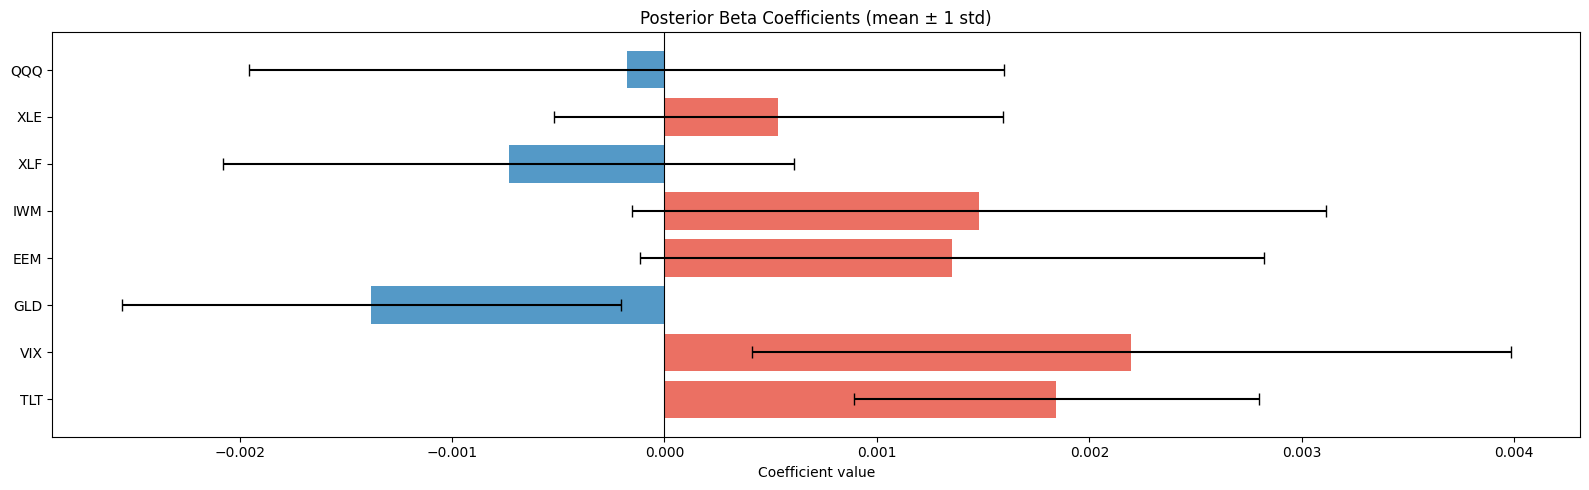

In [15]:
fig, ax = plt.subplots(figsize=(16, 5))
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in coef_df["beta_mean"]]
ax.barh(coef_df["ETF"], coef_df["beta_mean"], xerr=coef_df["beta_std"],
        color=colors, capsize=4, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Posterior Beta Coefficients (mean ± 1 std)")
ax.set_xlabel("Coefficient value")
fig.tight_layout()
plt.show()